Fidelity of X_{π/2} gate with T1 = 0.3 μs, T2 = 0.2 μs: 0.982283


/home/ubuntu-compute/miniconda3/envs/qdev/lib/python3.11/site-packages/qutip/solver/solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


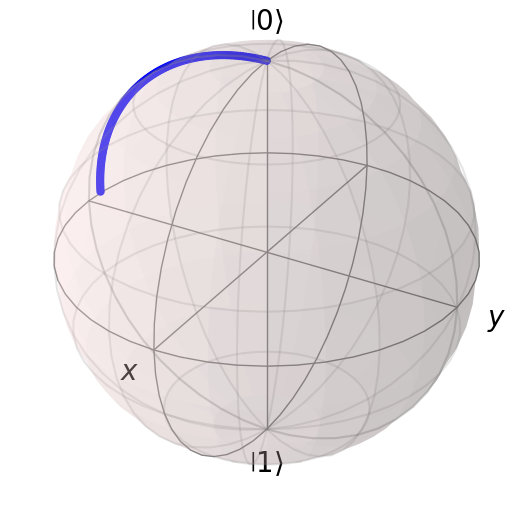

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import *

# Parameters
T1 = 3.0e-1     # relaxation time in microseconds
T2 = 2.0e-1     # dephasing time in microseconds
gate_time = 0.02  # gate duration in microseconds

# Operators
sx = sigmax()
sy = sigmay()
sz = sigmaz()
sm = destroy(2)

# Initial state |0>
psi0 = basis(2, 0)

# Hamiltonian for X_{pi/2} gate
# H = (pi/2) * sigma_x / gate_time
H = (np.pi / (2 * gate_time)) * sx / 2

# Collapse operators
c_ops = []

if T1 > 0.0:
    c_ops.append(np.sqrt(1.0 / T1) * sm)

if T2 > 0.0:
    gamma_phi = 1.0 / T2 - 0.5 / T1
    if gamma_phi > 0.0:
        c_ops.append(np.sqrt(gamma_phi) * sz)

# Time vector
tlist = np.linspace(0, gate_time, 100)

# Evolve system
result = mesolve(H, psi0, tlist, c_ops, [])

# Final state
rho_final = result.states[-1]

# Ideal target state: |ψ_target> = X_{π/2} |0>
U_ideal = (-1j * (np.pi/4) * sx).expm()
psi_target = U_ideal * psi0
rho_target = ket2dm(psi_target)

# Fidelity
fidelity_value = fidelity(rho_final, rho_target)

print(f"Fidelity of X_{{π/2}} gate with T1 = {T1} μs, T2 = {T2} μs: {fidelity_value:.6f}")

# Optional: Bloch vector evolution plot
bloch = Bloch()
x_vals = [expect(sx, state) for state in result.states]
y_vals = [expect(sy, state) for state in result.states]
z_vals = [expect(sz, state) for state in result.states]

bloch.add_points([x_vals, y_vals, z_vals])
bloch.show()

